In [1]:
# notebooks/ sits one level down, so point at the lesson modules and data.
# Written to be safe to re-run: it moves up only if it is not already there.
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
%matplotlib inline
print('working directory:', os.getcwd())

working directory: /home/user/chiu__2022_rerun/tk_learning


# Lesson 11 — Continuous exposure, and the bridge to Chiu's human model

Every lesson so far gave the animal ONE dose and watched it leave.
Humans are not dosed that way. They drink contaminated water every day
for years, and the question is not "how fast does a bolus clear" but
"what blood level does a given exposure produce, and how long does it
take to get there and to come back down".

Same compartment, same k, same Vd. Only the input term changes:


```text
bolus       dC/dt = -k*C,                  C(0) = dose/Vd
continuous  dC/dt = DWI*DWC/Vd - k*C,      C(0) = 0

DWC  drinking-water concentration   ug/L
DWI  water intake per kg body weight  L/kg/day
DWI*DWC  daily intake                 ug/kg/day
```

That second equation IS the model in ../chiu_replication/model.py, which Chiu et al.
2022 fitted to four PFAS in exposed US communities. By the end of this
lesson you will have built it, and the only thing left to add is the
hierarchy from lesson 06.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

import plotting as P
from tk import half_life, clearance

P.setup()

# Chiu's fitted human values for PFOA (Table 3 / ../chiu_replication/model.py priors).
# Note the units change from the animal lessons: humans are followed for
# years, so time is in years and concentration in ug/L.
DWI = np.exp(-4.3955)          # 0.0123 L/kg/day, fixed by Chiu, not fitted
HALFLIFE_Y = 3.14              # years
K = np.log(2) / HALFLIFE_Y     # 1/year
VD = 0.43                      # L/kg  (430 mL/kg, Chiu's fitted value)
DAYS = 365.25

## A. The equation, and its steady state

In [3]:
def rhs(t, state, dwc, k=K, vd=VD):
    """dC/dt for constant drinking-water exposure. Time in YEARS.

    DWI is per day, so multiply by 365.25 to get L/kg/year.
    """
    C, = state
    intake = DWI * DAYS * dwc          # ug/kg/year
    return [intake / vd - k * C]


print("A. One equation, two regimes\n")
CL = clearance(K, VD)
print(f"   k  = {K:.4f} /year   (half-life {HALFLIFE_Y} y)")
print(f"   Vd = {VD} L/kg")
print(f"   CL = k*Vd = {CL:.4f} L/kg/year = {CL/DAYS*1000:.4f} mL/kg/day\n")

BAF = DWI * DAYS / (K * VD)          # serum / water at steady state
print(f"   {'water (ug/L)':>13s} {'intake (ng/kg/day)':>19s} {'steady state (ug/L)':>21s}")
for dwc in [0.004, 0.02, 0.1, 1.0, 10.0]:
    print(f"   {dwc:13.3f} {1000*DWI*dwc:19.3f} {BAF*dwc:21.2f}")

A. One equation, two regimes

   k  = 0.2207 /year   (half-life 3.14 y)
   Vd = 0.43 L/kg
   CL = k*Vd = 0.0949 L/kg/year = 0.2599 mL/kg/day

    water (ug/L)  intake (ng/kg/day)   steady state (ug/L)
           0.004               0.049                  0.19
           0.020               0.247                  0.95
           0.100               1.233                  4.75
           1.000              12.333                 47.46
          10.000             123.327                474.55


Css = DWI*DWC/(k*Vd) = intake/CL. Vd has cancelled out of WHERE the
level settles -- it only sets HOW FAST you get there, through
k = CL/Vd. That is lesson 01 section C, now with real human numbers.

Sanity check the middle row: 0.1 ug/L in water, around the old US
health advisory level, produces a serum level near 5 ug/L.

In [4]:
print(f"   Serum runs {BAF:.0f}x the water concentration at steady state, and")
print(f"   that ratio is just DWI/CL -- no Vd, no exposure duration, nothing")
print(f"   else. It is the single most load-bearing number in PFAS risk")
print(f"   assessment, and it is inversely proportional to clearance.\n")

   Serum runs 47x the water concentration at steady state, and
   that ratio is just DWI/CL -- no Vd, no exposure duration, nothing
   else. It is the single most load-bearing number in PFAS risk
   assessment, and it is inversely proportional to clearance.



## B. How long to get there, and how long to come back

In [5]:
DWC = 0.1
years = np.linspace(0, 40, 4001)
up = solve_ivp(rhs, (0, 40), [0.0], t_eval=years, args=(DWC,),
               rtol=1e-9, atol=1e-12).y[0]
css = DWI * DAYS * DWC / (K * VD)

print(f"   drinking {DWC} ug/L from birth, steady state {css:.2f} ug/L\n")
print(f"   {'year':>6s} {'serum (ug/L)':>14s} {'% of Css':>10s} {'half-lives':>12s}")
for y in [1, 3.14, 5, 6.3, 10, 15, 20, 30]:
    i = np.argmin(np.abs(years - y))
    print(f"   {y:6.2f} {up[i]:14.2f} {100*up[i]/css:9.0f}% {y/HALFLIFE_Y:12.1f}")

# now switch to clean water at year 20 and watch it fall
def rhs_switch(t, state):
    return rhs(t, state, DWC if t < 20 else 0.0)

both = solve_ivp(rhs_switch, (0, 40), [0.0], t_eval=years,
                 rtol=1e-9, atol=1e-12).y[0]
after = years >= 20
print(f"\n   Town switches to clean water at year 20:\n")
print(f"   {'years after':>12s} {'serum (ug/L)':>14s} {'% of peak':>11s}")
peak = both[np.argmin(np.abs(years - 20))]
for dy in [0, 1, 3.14, 5, 10, 15, 20]:
    i = np.argmin(np.abs(years - (20 + dy)))
    print(f"   {dy:12.2f} {both[i]:14.2f} {100*both[i]/peak:10.0f}%")

   drinking 0.1 ug/L from birth, steady state 4.75 ug/L

     year   serum (ug/L)   % of Css   half-lives
     1.00           0.94        20%          0.3
     3.14           2.37        50%          1.0
     5.00           3.17        67%          1.6
     6.30           3.56        75%          2.0
    10.00           4.22        89%          3.2
    15.00           4.57        96%          4.8
    20.00           4.69        99%          6.4
    30.00           4.74       100%          9.6

   Town switches to clean water at year 20:

    years after   serum (ug/L)   % of peak
           0.00           4.69        100%
           1.00           3.76         80%
           3.14           2.34         50%
           5.00           1.55         33%
          10.00           0.52         11%
          15.00           0.17          4%
          20.00           0.06          1%


Symmetry worth noticing: the approach up and the decay down are
governed by the same k. It takes about 5 half-lives -- 15 years for
PFOA -- to arrive, and the same 15 years to leave. A community whose
water is cleaned up today still carries half its body burden three
years later, and a quarter of it after six.

This is why the half-life argument in ../literature/SYNTHESIS.md
matters so much in practice. If PFOA's half-life were 1.3 years (the
Zhang 2013 figure) rather than 3.14, both the steady-state level and
the recovery time would be 2.4x smaller. Same data, same people,
different policy.

## C. Realistic exposure: it is never constant

In [6]:
def rhs_history(t, state, history):
    """history(t) returns the water concentration at time t."""
    return rhs(t, state, history(t))


def contamination(t):
    """A plant opens in 1980, runs to 2005, filters installed 2015."""
    if t < 1980:
        return 0.002          # regional background
    if t < 2005:
        return 0.40           # plant discharging
    if t < 2015:
        return 0.08           # discharge stopped, aquifer still loaded
    return 0.004              # granular activated carbon installed


t_eval = np.linspace(1960, 2040, 8001)
hist = solve_ivp(rhs_history, (1960, 2040), [0.0], t_eval=t_eval,
                 args=(contamination,), rtol=1e-8, atol=1e-11,
                 max_step=0.5).y[0]

print(f"   {'year':>6s} {'water (ug/L)':>13s} {'serum (ug/L)':>14s}")
for y in [1975, 1985, 1995, 2005, 2010, 2015, 2020, 2030, 2040]:
    i = np.argmin(np.abs(t_eval - y))
    print(f"   {y:6d} {contamination(y):13.3f} {hist[i]:14.2f}")

     year  water (ug/L)   serum (ug/L)
     1975         0.002           0.09
     1985         0.400          12.72
     1995         0.400          18.29
     2005         0.080          18.91
     2010         0.080           8.81
     2015         0.004           5.46
     2020         0.004           1.94
     2030         0.004           0.38
     2040         0.004           0.21


Two things a closed-form solution could not have told you:

1. Serum LAGS water. The water improves sharply in 2005; serum is

```text
still falling in 2015. Anyone sampled in 2012 has a blood level
that reflects exposure from years earlier, not the water they are
drinking that day.
```

2. Serum SMOOTHS water. The body is a low-pass filter with a time

```text
constant of 1/k. Sharp changes in exposure become gradual changes
in blood.
```

Both are why cross-sectional studies that regress today's serum on
today's water get the wrong answer, and why Chiu's model has to
carry each community's full exposure history rather than one number.
`max_step=0.5` above is not decoration: without it the integrator
can step straight over a step change and miss it entirely.

## D. This is Chiu's model

You now have the kinetic core of Chiu et al. 2022. The published
model differs in four ways, none of them about the kinetics:


```text
background   dC/dt = DWI*DWC/Vd - k*(C - Cbgd). People are exposed
             through food and dust too, so the level decays toward
             a background Cbgd rather than toward zero.
hierarchy    k and Vd vary between people, drawn from a population
             distribution -- lesson 06, with three levels
             (population -> study -> person) instead of two.
priors       informative lognormal priors on k and Vd, so that
             communities with two blood samples per person still
             contribute.
calibration  DWI is FIXED, not fitted. With only serum data you
             cannot identify intake and volume separately -- the
             same identifiability problem as F and Vd in lesson 05.
```

Read ../chiu_replication/model.py now. It should look familiar rather than foreign:
the differential equation is the one in this file.

## E. Figures

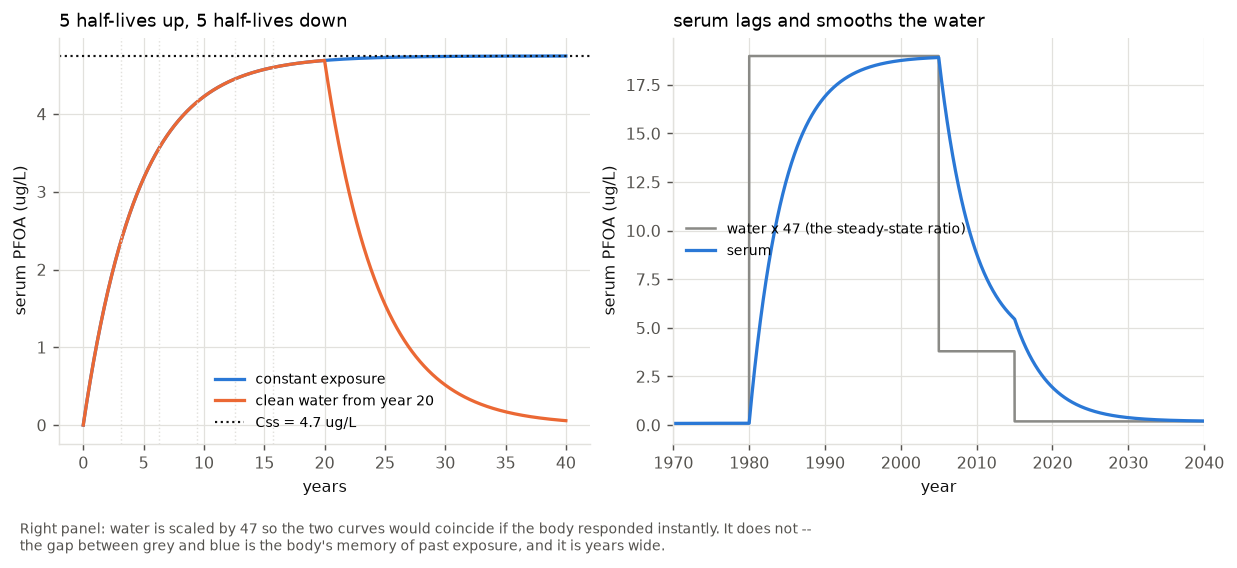

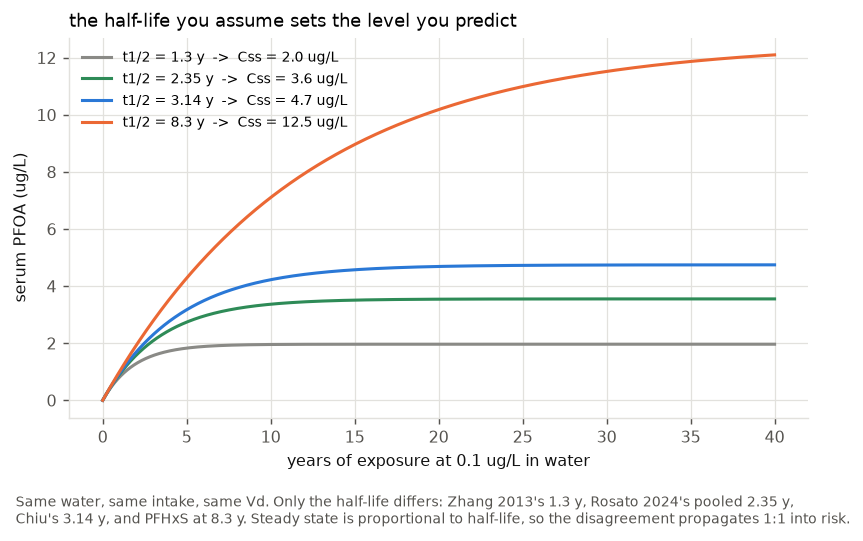

'/home/user/chiu__2022_rerun/tk_learning/figures/11_halflife_matters.png'

In [7]:
fig, (a, b) = plt.subplots(1, 2, figsize=(9.4, 3.8), constrained_layout=True)
a.plot(years, up, color=P.BLUE, lw=1.8, label="constant exposure")
a.plot(years, both, color=P.ORANGE, lw=1.8, label="clean water from year 20")
a.axhline(css, color=P.INK, ls=":", lw=1.2, label=f"Css = {css:.1f} ug/L")
for n in range(1, 6):
    a.axvline(n * HALFLIFE_Y, color=P.GRID, lw=0.8, ls=":")
a.set(xlabel="years", ylabel="serum PFOA (ug/L)")
a.set_title("5 half-lives up, 5 half-lives down")
a.legend(fontsize=8)

b.plot(t_eval, [contamination(t) * BAF for t in t_eval], color=P.GREY, lw=1.4,
       label=f"water x {BAF:.0f} (the steady-state ratio)")
b.plot(t_eval, hist, color=P.BLUE, lw=1.8, label="serum")
b.set(xlabel="year", ylabel="serum PFOA (ug/L)", xlim=(1970, 2040))
b.set_title("serum lags and smooths the water")
b.legend(fontsize=8)
P.save(fig, "11_continuous_dosing.png",
       f"Right panel: water is scaled by {BAF:.0f} so the two curves would "
       "coincide if the body responded instantly. It does not --\n"
       "the gap between grey and blue is the body's memory of past "
       "exposure, and it is years wide.")

fig, ax = plt.subplots(figsize=(6.2, 3.6), constrained_layout=True)
for hl, col in [(1.3, P.GREY), (2.35, P.GREEN), (3.14, P.BLUE), (8.3, P.ORANGE)]:
    k = np.log(2) / hl
    c = solve_ivp(lambda t, y: [DWI * DAYS * DWC / VD - k * y[0]], (0, 40),
                  [0.0], t_eval=years, rtol=1e-9).y[0]
    ax.plot(years, c, color=col, lw=1.7,
            label=f"t1/2 = {hl} y  ->  Css = {DWI*DAYS*DWC/(k*VD):.1f} ug/L")
ax.set(xlabel="years of exposure at 0.1 ug/L in water",
       ylabel="serum PFOA (ug/L)")
ax.set_title("the half-life you assume sets the level you predict")
ax.legend(fontsize=8)
P.save(fig, "11_halflife_matters.png",
       "Same water, same intake, same Vd. Only the half-life differs: "
       "Zhang 2013's 1.3 y, Rosato 2024's pooled 2.35 y,\nChiu's "
       "3.14 y, and PFHxS at 8.3 y. Steady state is proportional to "
       "half-life, so the disagreement propagates 1:1 into risk.")

### Questions

1. Css = intake/CL contains no Vd. But the CURVE in figure 11_continuous_dosing.png does depend on Vd. Where does it enter, and what would doubling Vd do to the picture?
1. A town's water is cleaned up completely. Someone argues residents' blood should be normal "within a year or two". Using section B, what would you tell them, and what do you need to know first?
1. Section C says serum lags water. If you regressed serum on CURRENT water concentration across many towns with different contamination histories, would you over- or under-estimate the relationship? Does it depend on whether contamination is rising or falling?
1. Figure 11_halflife_matters.png shows Css proportional to half-life at fixed Vd. Show that from Css = DWI*DWC/(k*Vd).
1. Why must DWI be fixed rather than fitted? Which other parameter would it trade off against, and which lesson met the same problem?

### Exercises

1. Add a background term: dC/dt = DWI*DWC/Vd - k*(C - Cbgd), with Cbgd = 0.5 ug/L. How does it change the steady state and the apparent rate of decline after cleanup?
1. Give the person a finite lifetime: start at birth with C = 0, and make DWI per kg fall with age as body weight rises. Does the peak move?
1. Model a pregnancy: a 9-month window during which some of the mother's burden transfers out. What does that do to her curve, and what does it imply about using maternal serum to estimate exposure?
1. Take the exposure history in section C and try to recover k from serum measurements alone, sampled once per person at a random year. How many people do you need before k is identified? This is Chiu's actual inference problem.